In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bernardomoraes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
data = pd.read_csv('emails.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
data.shape

(5171, 4)

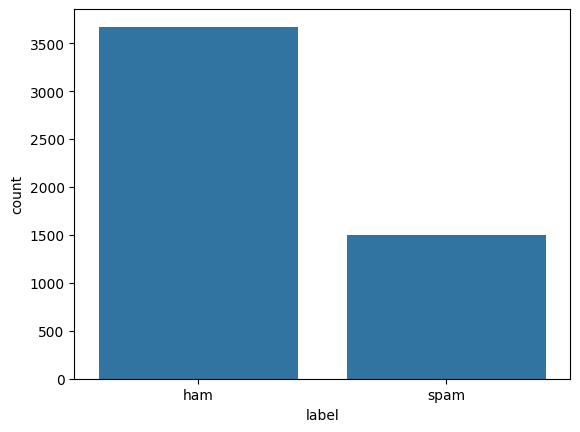

In [5]:
sns.countplot(x='label', data=data)
plt.show()

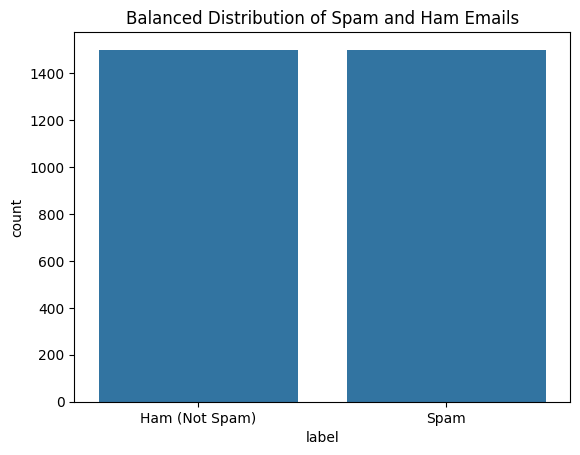

In [6]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

sns.countplot(x='label', data=balanced_data)
plt.title('Balanced Distribution of Spam and Ham Emails')
plt.xticks(ticks=[0,1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

In [7]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [8]:
punctuations_list = string.punctuation

def remove_punctuations(text):
  temp = str.maketrans('', '', punctuations_list)
  return text.translate(temp)

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [9]:
def remove_stopwords(text):
  stop_words = stopwords.words('english')

  imp_words = []

  for word in str(text).split():
    word = word.lower()

    if word not in stop_words:
      imp_words.append(word)

  output = " ".join(imp_words)

  return output

balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


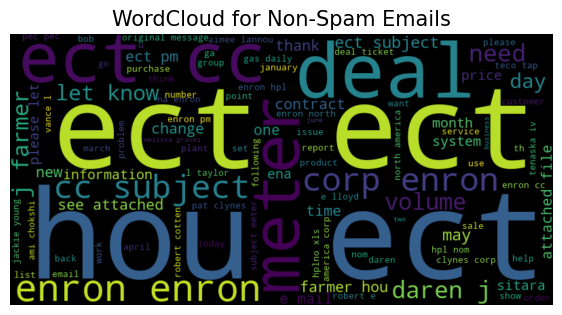

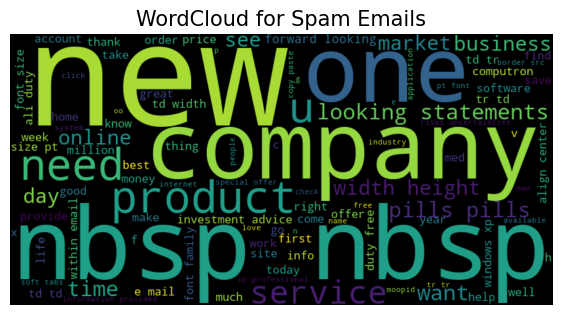

In [10]:
def plot_word_cloud(data, typ):
  email_corpus = " ".join(data['text'])
  wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
  plt.figure(figsize=(7,7))
  plt.imshow(wc,interpolation='bilinear')
  plt.title(f'WordCloud for {typ} Emails', fontsize=15)
  plt.axis('off')
  plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

In [ ]:
train_X, test_X, train_Y, test_Y = train_test_split(balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42)

tokenizer=Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)



{'ect': 1, 'hou': 2, 'enron': 3, '2000': 4, 'com': 5, '3': 6, 'please': 7, '1': 8, '2': 9, '00': 10, 'gas': 11, 'subject': 12, 'e': 13, 'deal': 14, 'meter': 15, 'http': 16, 'cc': 17, '000': 18, 'pm': 19, '10': 20, '0': 21, '5': 22, 'company': 23, '4': 24, 'may': 25, 'new': 26, 'get': 27, 'daren': 28, 'hpl': 29, 'thanks': 30, 'information': 31, 'corp': 32, '2001': 33, 'price': 34, '7': 35, 'need': 36, '01': 37, 'know': 38, '99': 39, 'us': 40, 'www': 41, 'email': 42, '9': 43, 'see': 44, '11': 45, 'one': 46, '12': 47, 'time': 48, '6': 49, 'j': 50, '03': 51, 'forwarded': 52, '8': 53, 'would': 54, 'mail': 55, 'p': 56, 'statements': 57, 'l': 58, 'message': 59, 'font': 60, 'mmbtu': 61, 'farmer': 62, '20': 63, 'day': 64, 'nbsp': 65, '30': 66, 'let': 67, 'b': 68, '15': 69, '02': 70, 'also': 71, 'attached': 72, 'th': 73, 'month': 74, 'xls': 75, 'x': 76, 'energy': 77, '04': 78, 'like': 79, '09': 80, 'c': 81, 'inc': 82, 'free': 83, 'report': 84, 'within': 85, 'business': 86, 'volume': 87, '08': 88

In [2]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5801 - loss: 0.6777 - val_accuracy: 0.7567 - val_loss: 0.5337 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8724 - loss: 0.3619 - val_accuracy: 0.9017 - val_loss: 0.3042 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9241 - loss: 0.2462 - val_accuracy: 0.9083 - val_loss: 0.2951 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9295 - loss: 0.2338 - val_accuracy: 0.9000 - val_loss: 0.3152 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9045 - loss: 0.2771 - val_accuracy: 0.8100 - val_loss: 0.4324 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8432 - loss: 0.3483 - val_accuracy: 0.8700 - val_loss: 0.3174 - learning_rate: 5.0000e-04


In [14]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9083 - loss: 0.2951
Test Loss : 0.2950938045978546
Test Accuracy : 0.9083333611488342


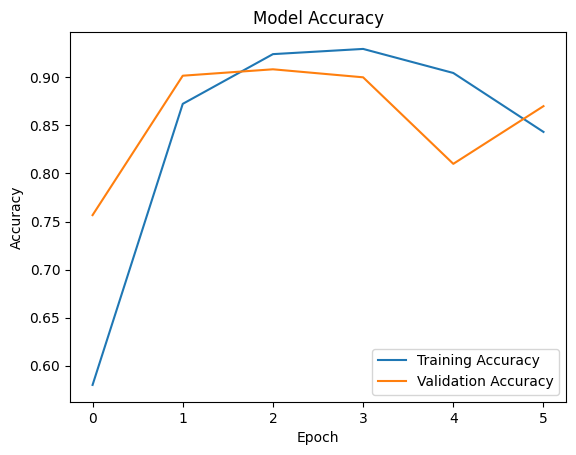

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()